In [4]:
%pip install langchain langchain-groq langchain-community langgraph python-dotenv faiss-cpu pypdf sentence-transformers


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
from typing import Annotated

from langchain_groq import ChatGroq
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage


In [7]:

load_dotenv()


True

In [8]:
import os
llm = ChatGroq(model="llama-3.3-70b-versatile",temperature=0, groq_api_key=os.getenv("GROQ_API_KEY"))

In [9]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage],add_messages]

In [16]:
def chat_node(state: ChatState):

    decision =interrupt({
        "type":"approval",
        "reason":"Model is about to answer a user question",
        "instruction":"Approve this question? yes/no"
    })

    if decision["approved"] == 'no':
        return {"messages" : [AIMessage(content="Not Approved")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages" :[response]}

In [17]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
#not using a database here , only an in memeory saver 
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

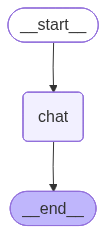

In [18]:
app


In [19]:
#Create a new thread id for this conversation 

config = {"configurable":{"thread_id":'1234'}}

initial_input ={
    "messages":[
        ("user" , "Explain Gradient descent in very simple terms")
    ]
}

#Invoke the graph for the first time 
result = app.invoke(initial_input , config=config)

In [20]:
result

{'messages': [HumanMessage(content='Explain Gradient descent in very simple terms', additional_kwargs={}, response_metadata={}, id='a6e2c6cd-6799-4355-aedf-066ace8d2e82')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question', 'instruction': 'Approve this question? yes/no'}, id='8d196ff5300fe6fe5d627df1940e9563')]}

In [21]:
message= result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question',
 'instruction': 'Approve this question? yes/no'}

In [22]:
user_input = input(f"\nBackend message -{message} \n Approve this question?(y/n):")

In [23]:
#resume the graph with the approval decsion 

final_result = app.invoke(
    Command(resume={"approved":user_input}),
    config = config,
) 

In [24]:
print(final_result)

{'messages': [HumanMessage(content='Explain Gradient descent in very simple terms', additional_kwargs={}, response_metadata={}, id='a6e2c6cd-6799-4355-aedf-066ace8d2e82'), AIMessage(content='Not Approved', additional_kwargs={}, response_metadata={}, id='f28151b0-fbe5-470d-8bd8-ba882cf19720', tool_calls=[], invalid_tool_calls=[])]}
